In [32]:
import numpy as np
from tifffile import imread
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F


In [33]:
# ── Load 3D volume ────────────────────────────────────────────────────────
DATA_DIR = '260227_ID459_laminB1antibody'

img_vol  = imread(f'{DATA_DIR}/ST28_stable_emb2_-01_nuclei.tif')       # (Z, Y, X)
mask_vol = imread(f'{DATA_DIR}/ST28_stable_emb2_-01_nuclei_anno.tif')  # (Z, Y, X) instance labels

print(f"image: {img_vol.shape}  mask: {mask_vol.shape}")
print(f"annotated nuclei: {len(np.unique(mask_vol)) - 1}")


image: (66, 1024, 1024)  mask: (66, 1024, 1024)
annotated nuclei: 58


In [35]:
# ── Augmentation: 4 XY-rotations × 2 Z-flips = 8 volumes ────────────────
def augment_3d(img, msk):
    """img, msk: (Z, Y, X). Returns list of (img, msk) augmented pairs."""
    pairs = []
    for k in range(4):                              # 0°, 90°, 180°, 270° in XY
        ri = np.rot90(img, k, axes=(1, 2))
        rm = np.rot90(msk, k, axes=(1, 2))
        pairs.append((np.ascontiguousarray(ri), np.ascontiguousarray(rm)))
        pairs.append((np.ascontiguousarray(np.flip(ri, axis=0)),   # Z flip
                      np.ascontiguousarray(np.flip(rm, axis=0))))
    return pairs

aug_volumes = augment_3d(img_vol, mask_vol)
print(f"augmented volumes: {len(aug_volumes)}")   # 8


augmented volumes: 8


In [37]:
# ── Patch-based Dataset ───────────────────────────────────────────────────
# 1024×1024 slices are too large for a full-volume forward pass.
# We randomly sample small 3D patches; patches must contain at least one nucleus.
PATCH = (32,256,256)   # (Z, Y, X) patch size — tune to your GPU memory

class NucleiDataset3D(Dataset):
    def __init__(self, volumes, patch_size=PATCH, patches_per_vol=20):
        self.vols       = volumes          # list of (img, mask) tuples
        self.pz, self.py, self.px = patch_size
        self.n          = patches_per_vol
        # pre-sample patch coordinates
        self.samples = []
        for vol_idx, (img, msk) in enumerate(self.vols):
            Z, Y, X = img.shape
            attempts = 0
            found    = 0
            while found < self.n and attempts < self.n * 50:
                attempts += 1
                z0 = np.random.randint(0, max(1, Z - self.pz))
                y0 = np.random.randint(0, max(1, Y - self.py))
                x0 = np.random.randint(0, max(1, X - self.px))
                patch_msk = msk[z0:z0+self.pz, y0:y0+self.py, x0:x0+self.px]
                if patch_msk.max() > 0:             # must contain a nucleus
                    self.samples.append((vol_idx, z0, y0, x0))
                    found += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vol_idx, z0, y0, x0 = self.samples[idx]
        img, msk = self.vols[vol_idx]

        patch_img = img[z0:z0+self.pz, y0:y0+self.py, x0:x0+self.px].astype(np.float32)
        patch_msk = msk[z0:z0+self.pz, y0:y0+self.py, x0:x0+self.px]

        # normalize image to [0, 1]
        patch_img = (patch_img - patch_img.min()) / (patch_img.max() - patch_img.min() + 1e-8)
        patch_msk = (patch_msk > 0).astype(np.float32)   # binary foreground mask

        return (torch.from_numpy(patch_img).unsqueeze(0),   # (1, Z, Y, X)
                torch.from_numpy(patch_msk).unsqueeze(0))   # (1, Z, Y, X)

dataset    = NucleiDataset3D(aug_volumes, patch_size=PATCH, patches_per_vol=20)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
print(f"dataset size: {len(dataset)},  batches: {len(dataloader)}")


dataset size: 160,  batches: 80


In [38]:
# ── 3D U-Net ─────────────────────────────────────────────────────────────
class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1), nn.BatchNorm3d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet3D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=[16, 32, 64, 128]):
        super().__init__()
        self.downs, self.pool = nn.ModuleList(), nn.MaxPool3d(2)
        self.up_convs, self.ups = nn.ModuleList(), nn.ModuleList()

        ch = in_ch
        for f in features:
            self.downs.append(ConvBlock3D(ch, f)); ch = f

        self.bottleneck = ConvBlock3D(ch, ch * 2); ch = ch * 2

        for f in reversed(features):
            self.up_convs.append(nn.ConvTranspose3d(ch, f, kernel_size=2, stride=2))
            self.ups.append(ConvBlock3D(f * 2, f)); ch = f

        self.head = nn.Conv3d(ch, out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for up_conv, up, skip in zip(self.up_convs, self.ups, reversed(skips)):
            x = up_conv(x)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = up(torch.cat([skip, x], dim=1))
        return self.head(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = UNet3D().to(device)
print(f"3D U-Net ready on {device}")
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


3D U-Net ready on cuda
parameters: 5,647,857


In [41]:
# ── Loss: weighted BCE + Dice ─────────────────────────────────────────────
def dice_loss(pred, target, smooth=1.0):
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    inter  = (pred * target).sum()
    return 1 - (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)

def bce_dice_loss(pred, target, pos_weight):
    bce  = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight)
    return bce + dice_loss(pred, target)

# estimate foreground/background ratio from training masks
all_masks   = torch.stack([m for _, m in dataset], dim=0)
fg          = all_masks.mean().item()
pos_weight  = torch.tensor([(1 - fg) / (fg + 1e-6)]).to(device)
print(f"foreground fraction: {fg:.3f}  →  pos_weight: {pos_weight.item():.1f}")

# ── Training ──────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, verbose=True)

EPOCHS = 200
losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for imgs, msks in dataloader:
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        loss = bce_dice_loss(model(imgs), msks, pos_weight)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(dataloader)
    losses.append(avg)
    scheduler.step(avg)
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}/{EPOCHS}  loss={avg:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

torch.save(model.state_dict(), 'model/unet3d_nuclei.pth')
print("model saved to model/unet3d_nuclei.pth")


foreground fraction: 0.109  →  pos_weight: 8.2
epoch  10/200  loss=0.1242  lr=1.00e-04
epoch  20/200  loss=0.1109  lr=1.00e-04
epoch  30/200  loss=0.1061  lr=1.00e-04
epoch  40/200  loss=0.1010  lr=1.00e-04
epoch  50/200  loss=0.0998  lr=1.00e-04
epoch  60/200  loss=0.0835  lr=1.00e-04
epoch  70/200  loss=0.0849  lr=1.00e-04
epoch  80/200  loss=0.0801  lr=1.00e-04
epoch  90/200  loss=0.0648  lr=5.00e-05
epoch 100/200  loss=0.0628  lr=5.00e-05
epoch 110/200  loss=0.0604  lr=5.00e-05
epoch 120/200  loss=0.0598  lr=5.00e-05
epoch 130/200  loss=0.0563  lr=5.00e-05
epoch 140/200  loss=0.0545  lr=5.00e-05
epoch 150/200  loss=0.0542  lr=5.00e-05
epoch 160/200  loss=0.0498  lr=5.00e-05
epoch 170/200  loss=0.0495  lr=5.00e-05
epoch 180/200  loss=0.0473  lr=5.00e-05
epoch 190/200  loss=0.0455  lr=5.00e-05
epoch 200/200  loss=0.0428  lr=5.00e-05
model saved to model/unet3d_nuclei.pth


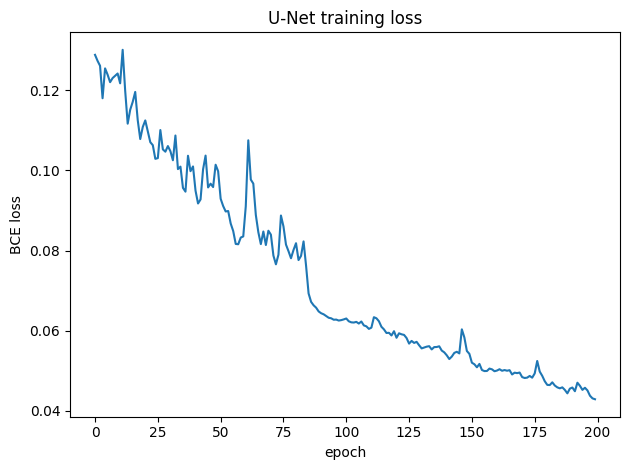

In [42]:
# ── Loss curve ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('epoch'); plt.ylabel('BCE loss'); plt.title('U-Net training loss')
plt.tight_layout(); plt.savefig('model/unet_loss.png'); plt.show()


# load and predict

In [43]:
# ── Load ──────────────────────────────────────────────────────────────────
raw = imread('260227_ID459_laminB1antibody/ST28_WT_emb1_-02.tif')
print("raw shape:", raw.shape, " dtype:", raw.dtype)

# extract nuclei channel (axis 1 = channel dim for 4-channel tifs)
if raw.ndim == 4:                        # (Z, C, Y, X)
    img = raw[:, 1, :, :]
elif raw.ndim == 3:                      # already (Z, Y, X)
    img = raw
img = img.astype(np.float32)
img = (img - img.min()) / (img.max() - img.min() + 1e-8)
print("input to model:", img.shape)     # should be (Z, Y, X)


raw shape: (81, 4, 1024, 1024)  dtype: uint16
input to model: (81, 1024, 1024)


In [44]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = UNet3D().to(device)
model.load_state_dict(torch.load('model/unet3d_nuclei.pth', map_location=device))
model.eval()
print("model loaded")


model loaded


In [45]:
# ── Sliding-window predict ────────────────────────────────────────────────
pz, py, px = 32, 256, 256   # must match training patch size
Z, Y, X    = img.shape

prob_sum  = np.zeros((Z, Y, X), dtype=np.float32)
count_map = np.zeros((Z, Y, X), dtype=np.float32)

model.eval()
with torch.no_grad():
    for z0 in range(0, Z, pz // 2):
        z0 = min(z0, Z - pz)
        for y0 in range(0, Y, py // 2):
            y0 = min(y0, Y - py)
            for x0 in range(0, X, px // 2):
                x0 = min(x0, X - px)
                patch = img[z0:z0+pz, y0:y0+py, x0:x0+px]
                t     = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)
                out   = torch.sigmoid(model(t)).squeeze().cpu().numpy()
                prob_sum [z0:z0+pz, y0:y0+py, x0:x0+px] += out
                count_map[z0:z0+pz, y0:y0+py, x0:x0+px] += 1

prob = prob_sum / count_map
seg  = (prob > 0.5).astype(np.uint8)
print("prediction shape:", seg.shape, " foreground:", seg.sum())


prediction shape: (81, 1024, 1024)  foreground: 3698263


In [46]:
import napari
viewer = napari.Viewer()
viewer.add_image(img, name='input nuclei', colormap='gray_r')
viewer.add_image(prob, name='predicted probability', colormap='magma')
viewer.add_labels(seg, name='predicted mask')


c:\Users\ljd567\AppData\Local\miniconda3\envs\torch_env\lib\site-packages\napari\plugins\_plugin_manager.py:555: UserWarning: Plugin 'napari_skimage_regionprops2' has already registered a function widget 'duplicate current frame' which has now been overwritten
  warn(message=warn_message)


<Labels layer 'predicted mask' at 0x251a8cdbd60>

In [16]:
import napari

viewer = napari.Viewer()
viewer.add_image(img, name='input nuclei', colormap='gray_r')
viewer.add_image(prob, name='predicted probability', colormap='magma')
viewer.add_labels(seg, name='predicted mask')

<Labels layer 'predicted mask' at 0x25270da1e50>